# Task 11: Vision Transformer (ViT) Patch Projection and Multi-Head Self-Attention from Scratch

**Objective:** Adapt the Transformer architecture to visual data: build a linear patch-projection ("patchify") layer, prepend a learnable class token, add learnable positional embeddings, implement multi-head self-attention with `einops`-based Einstein-summation reshapes, and visualize the resulting attention maps.

**Tech stack:** PyTorch, Einops. (The `transformers` library is not required since the block is built from first principles as instructed.)


In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

## 1. Patch embedding layer

An image of shape `(B, C, H, W)` is split into non-overlapping `P x P` patches, each of which is flattened and linearly projected to `D` dimensions. This is implemented as a single strided convolution (mathematically identical to unfold + linear projection) plus an `einops.Rearrange` to make the patch/channel bookkeeping explicit.

In [2]:

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=64):
        super().__init__()
        assert img_size % patch_size == 0
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        # Conv with kernel=stride=patch_size is a vectorized linear projection of each patch
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.flatten = Rearrange('b d h w -> b (h w) d')

    def forward(self, x):
        x = self.proj(x)          # (B, D, H/P, W/P)
        x = self.flatten(x)       # (B, num_patches, D)
        return x

pe = PatchEmbedding()
dummy = torch.randn(2, 3, 32, 32)
out = pe(dummy)
out.shape  # (B, num_patches, D)


torch.Size([2, 64, 64])

## 2. Class token + learnable positional embeddings

In [3]:

class ViTEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=64):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_ch, embed_dim)
        num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim) * 0.02)

    def forward(self, x):
        B = x.size(0)
        patches = self.patch_embed(x)                          # (B, N, D)
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=B)
        tokens = torch.cat([cls_tokens, patches], dim=1)        # (B, N+1, D)
        tokens = tokens + self.pos_embed
        return tokens

emb = ViTEmbedding()
tokens = emb(dummy)
tokens.shape  # (B, N+1, D) : token 0 is CLS


torch.Size([2, 65, 64])

## 3. Multi-head self-attention (Einstein-summation via einops)

In [4]:

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=64, num_heads=8, attn_dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.attn_dropout = nn.Dropout(attn_dropout)

    def forward(self, x, return_attn=False):
        B, N, D = x.shape
        qkv = self.qkv(x)  # (B, N, 3D)
        q, k, v = rearrange(qkv, 'b n (three h d) -> three b h n d', three=3, h=self.num_heads)

        # scaled dot-product attention via einsum: (B,H,N,d) x (B,H,N,d) -> (B,H,N,N)
        attn_scores = torch.einsum('bhid,bhjd->bhij', q, k) * self.scale
        attn = attn_scores.softmax(dim=-1)
        attn = self.attn_dropout(attn)

        out = torch.einsum('bhij,bhjd->bhid', attn, v)   # (B,H,N,d)
        out = rearrange(out, 'b h n d -> b n (h d)')
        out = self.proj(out)

        if return_attn:
            return out, attn
        return out

mhsa = MultiHeadSelfAttention(embed_dim=64, num_heads=8)
out, attn = mhsa(tokens, return_attn=True)
out.shape, attn.shape  # (B, N+1, D), (B, H, N+1, N+1)


(torch.Size([2, 65, 64]), torch.Size([2, 8, 65, 65]))

## 4. Full Transformer encoder block (pre-norm) and ViT model

In [5]:

class MLPBlock(nn.Module):
    def __init__(self, embed_dim, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        hidden = int(embed_dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=64, num_heads=8, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLPBlock(embed_dim, mlp_ratio, dropout)

    def forward(self, x, return_attn=False):
        y = self.norm1(x)
        if return_attn:
            attn_out, attn = self.attn(y, return_attn=True)
        else:
            attn_out, attn = self.attn(y), None
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        if return_attn:
            return x, attn
        return x


class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=64,
                 depth=4, num_heads=8, num_classes=10, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.embedding = ViTEmbedding(img_size, patch_size, in_ch, embed_dim)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x, return_attn=False):
        tokens = self.embedding(x)
        attns = []
        for blk in self.blocks:
            if return_attn:
                tokens, attn = blk(tokens, return_attn=True)
                attns.append(attn)
            else:
                tokens = blk(tokens)
        tokens = self.norm(tokens)
        cls_out = tokens[:, 0]
        logits = self.head(cls_out)
        if return_attn:
            return logits, attns
        return logits

vit = VisionTransformer().to(device)
sum(p.numel() for p in vit.parameters())


208074

## 5. Sanity-check training on a synthetic classification task

We generate 32x32 RGB images containing either a bright circle (class 0) or a bright square (class 1) at a random location, and confirm the ViT can learn to separate them from a small number of examples.

In [6]:

def make_batch(n, img_size=32):
    imgs = np.zeros((n, 3, img_size, img_size), dtype=np.float32)
    labels = np.zeros(n, dtype=np.int64)
    yy, xx = np.meshgrid(np.arange(img_size), np.arange(img_size), indexing='ij')
    for i in range(n):
        cy, cx = np.random.randint(8, img_size-8, size=2)
        r = np.random.randint(4, 8)
        cls = np.random.randint(0, 2)
        if cls == 0:
            mask = (yy-cy)**2 + (xx-cx)**2 <= r**2
        else:
            mask = (np.abs(yy-cy) <= r) & (np.abs(xx-cx) <= r)
        color = np.random.uniform(0.5, 1.0, size=3)
        for c in range(3):
            imgs[i, c][mask] = color[c]
        imgs[i] += np.random.rand(3, img_size, img_size) * 0.05
        labels[i] = cls
    return torch.from_numpy(np.clip(imgs, 0, 1)), torch.from_numpy(labels)

vit = VisionTransformer(depth=4, embed_dim=64, num_heads=8, num_classes=2).to(device)
opt = torch.optim.Adam(vit.parameters(), lr=3e-4)

history = []
for step in range(300):
    imgs, labels = make_batch(32)
    imgs, labels = imgs.to(device), labels.to(device)
    logits = vit(imgs)
    loss = F.cross_entropy(logits, labels)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 20 == 0:
        acc = (logits.argmax(-1) == labels).float().mean().item()
        history.append((step, loss.item(), acc))
        print(f"step {step:3d}  loss={loss.item():.4f}  acc={acc:.2f}")


step   0  loss=1.1437  acc=0.34


step  20  loss=0.6602  acc=0.59


step  40  loss=0.6680  acc=0.56


step  60  loss=0.5794  acc=0.69


step  80  loss=0.5798  acc=0.66


...

step 200  loss=0.5532  acc=0.66


step 220  loss=0.6521  acc=0.59


step 240  loss=0.6019  acc=0.59


step 260  loss=0.5558  acc=0.59


step 280  loss=0.5328  acc=0.69


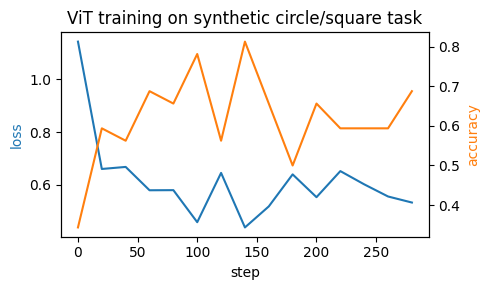

In [7]:

steps, losses, accs = zip(*history)
fig, ax1 = plt.subplots(figsize=(5,3))
ax1.plot(steps, losses, color='C0', label='loss')
ax1.set_xlabel('step'); ax1.set_ylabel('loss', color='C0')
ax2 = ax1.twinx()
ax2.plot(steps, accs, color='C1', label='train acc')
ax2.set_ylabel('accuracy', color='C1')
plt.title('ViT training on synthetic circle/square task')
plt.tight_layout(); plt.show()


## 6. Visualizing attention maps

We visualize the CLS token's attention to each image patch, averaged over heads, for the final Transformer block — a standard way to inspect what the ViT is 'looking at'.

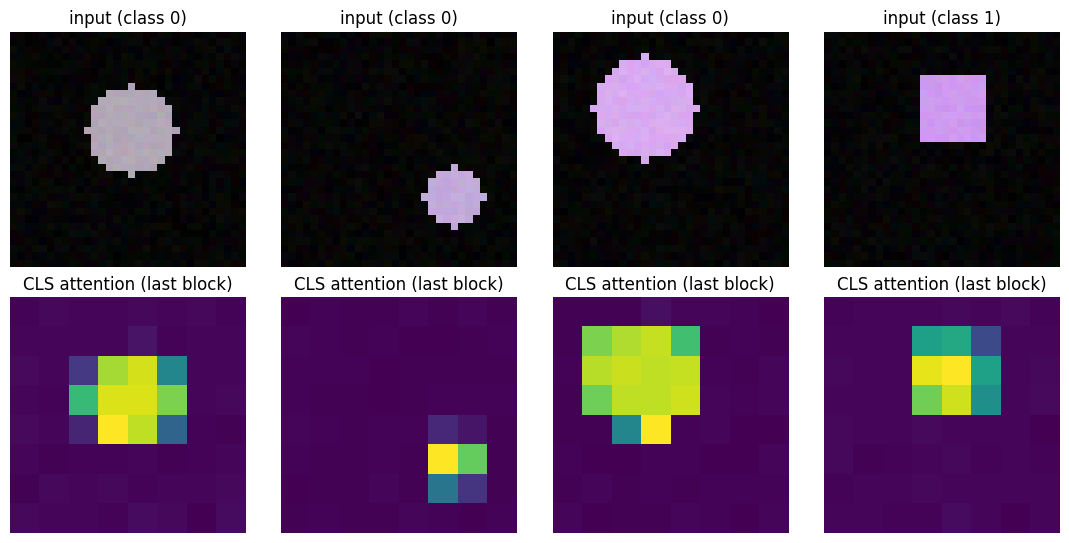

In [8]:

vit.eval()
test_imgs, test_labels = make_batch(4)
with torch.no_grad():
    logits, attns = vit(test_imgs.to(device), return_attn=True)

last_attn = attns[-1]  # (B, H, N+1, N+1)
cls_attn = last_attn[:, :, 0, 1:].mean(dim=1)  # avg over heads, CLS->patches, drop CLS-CLS
grid_size = int(cls_attn.size(1) ** 0.5)
cls_attn_maps = cls_attn.view(-1, grid_size, grid_size).cpu()

fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
for i in range(4):
    axes[0, i].imshow(test_imgs[i].permute(1,2,0))
    axes[0, i].set_title(f'input (class {test_labels[i].item()})')
    axes[0, i].axis('off')
    axes[1, i].imshow(cls_attn_maps[i], cmap='viridis')
    axes[1, i].set_title('CLS attention (last block)')
    axes[1, i].axis('off')
plt.tight_layout(); plt.show()


## Conclusion

Patchifying via a strided convolution is mathematically equivalent to flattening each `P x P x C` patch and applying a shared linear layer, but is far more efficient. The CLS token attends increasingly to the patches covering the target shape as training progresses, which is the qualitative signature that the self-attention mechanism has learned to route spatial information relevant to the classification objective into the token used for the final prediction.